# MIT-BIH Temporal Structure Exploration — Design Notes for Quorum

**Purpose.** This notebook is an exploratory data analysis of the MIT-BIH Arrhythmia Database, aimed at understanding the dataset's temporal structure well enough to guide future temporal modifications to **Quorum**, this project's zero-training quantum anomaly detector. It does **not** train, evaluate, or optimize any model — Quorum's own scripts (`main.py`, `data_bucketing.py`, `feature_selection.py`) already do that.

**What this notebook looks for:**
- Where morphology differs between normal and anomalous beats.
- Whether RR-interval (rhythm) structure separates normal from anomalous beats.
- Where strong autocorrelation / temporal dependence lives inside a beat window.
- Whether nearby time positions carry redundant (highly correlated) information — relevant to *how* Quorum should group features for amplitude encoding.
- Whether Dynamic Time Warping (DTW) captures morphological differences that plain Euclidean distance misses, and whether DTW-based similarity naturally separates or clusters anomalies — relevant to *how* Quorum should bucket beats.
- Whether the current 180-sample (`window_half=90`) beat window is well-sized.

**What this notebook does not do.** It does not propose or implement specific algorithmic changes to Quorum. The final *Summary* section only states what was observed, whether it plausibly motivates a change, and how confident that reading is — design decisions belong in a follow-up discussion, not here.

**Preprocessing pipeline.** All beats below are extracted with the same rules Quorum already uses (see `Preprocessing/mitbih_preprocess.py`):
- Original PhysioNet MIT-BIH records, MLII lead only.
- Beat-centered windows of 180 samples (90 on each side of the annotated R-peak).
- Rhythm/noise annotation markers (`+ ~ [ ] ! |`) are ignored — they are not beats.
- Label `N` means normal; every other beat-type label is treated as anomalous.

One deliberate deviation: this notebook keeps raw, un-normalized amplitude values instead of applying `normalize_for_quorum`. That min-max-plus-`1/sqrt(n_features)` scaling exists to satisfy Quorum's amplitude-encoding constraint (squared norm at most 1); it has no analytical benefit here and would distort DTW distances, autocorrelation, and Pearson/Spearman correlation, all of which should reflect true ECG morphology rather than an encoding-driven rescaling.

## Contents
0. Setup & Data Loading
1. Dataset Overview
2. Beat Visualization
3. RR Interval Analysis
4. Autocorrelation Analysis
5. Correlation Analysis
6. Dynamic Time Warping Analysis
7. Similarity Structure
8. Window Analysis
9. Summary

## 0. Setup & Data Loading

Constants, plot styling, and the running `FINDINGS` list that the Summary section renders at the end. Run this notebook from the repository root (the same working-directory convention `main.py` uses), so the relative `Data/MIT_BIH` path below resolves correctly.

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

from scipy import stats
from scipy.signal import find_peaks
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from Preprocessing.mitbih_preprocess import parse_annotations, load_signal, NORMAL_LABEL

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Data / preprocessing config (mirrors Preprocessing/mitbih_preprocess.py and main.py) ---
DATA_DIR = "Data/MIT_BIH"
WINDOW_HALF = 90          # samples each side of the R-peak -> 180-sample window
WINDOW_LEN = 2 * WINDOW_HALF
LEAD = "MLII"
FS = 360                  # MIT-BIH sampling rate, Hz (all records in this database)
RANDOM_SEED = 42

# Same record list used by main.py's MITBIH_RECORDS -- three patient/arrhythmia
# groups (normal-heavy, PVC-heavy/ventricular, AF/supraventricular) per PhysioNet's
# published record characteristics. Loading below skips any record that is not
# found locally with a [WARNING] instead of failing, so this list does not need
# to be hand-verified against the local Data/MIT_BIH folder first.
MITBIH_RECORDS = ["100", "101", "103", "106", "119", "208", "201", "210", "221"]

rng = np.random.default_rng(RANDOM_SEED)

# --- Plot styling: fixed categorical hue order, single-hue sequential ramp,
# blue<->red diverging with a neutral midpoint -- never a rainbow, never dual-axis.
COLOR_NORMAL  = "#2a78d6"   # categorical slot 1 (blue)  -- normal beats
COLOR_ANOMALY = "#eb6834"   # categorical slot 2 (orange) -- anomalous beats
COLOR_MIXED   = "#1baf7a"   # categorical slot 3 (aqua)   -- normal-anomaly pairs

SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "diverging_blue_red", ["#104281", "#5598e7", "#f0efec", "#ec8f82", "#c0392b"]
)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "font.size": 10,
    "axes.titleweight": "bold",
})

# --- Running list of findings, populated by each section, rendered in the Summary ---
FINDINGS = []

def record_finding(section, observation, motivates_change, confidence, note=""):
    """
    Append one structured finding to FINDINGS (rendered as a table in Section 9).
    motivates_change / confidence are short qualitative strings on purpose --
    this notebook draws conclusions about the data, not about a specific
    algorithmic change, so the summary stays qualitative and human-checkable.
    """
    FINDINGS.append({
        "section": section,
        "observation": observation,
        "motivates_quorum_change": motivates_change,
        "confidence": confidence,
        "note": note,
    })

print("Config loaded.")

Config loaded.


### Beat loader

`Preprocessing/mitbih_preprocess.py` already provides `parse_annotations` and `load_signal` (record I/O) and `extract_beat_windows` (windowing + feature flattening for Quorum's amplitude encoding). This notebook reuses the first two directly, but re-implements windowing locally (`load_record_beats` below) instead of calling `extract_beat_windows`, because the notebook needs three things that function does not expose:
- the raw label string for every beat (for the anomaly-class breakdown), not just a binary anomaly flag;
- the raw window with no `diff` features appended (DTW / autocorrelation / correlation should see the actual ECG amplitude trace, not a flattened `[window, diff, rr]` vector);
- both the preceding and following RR interval, in samples.

Everything else — R-peak-centered windowing, boundary handling, MLII-only, the skip-label set, `N` meaning normal — is identical to Quorum's own pipeline.

In [3]:
def load_record_beats(data_dir, record_id, window_half=WINDOW_HALF, lead=LEAD):
    """
    Load one MIT-BIH record and extract raw beat-centered windows + metadata.

    Returns a list of dicts (one per beat that survived the boundary check),
    each with: record_id, beat_pos (order within the record), sample (R-peak
    sample index), label, is_anomaly, rr_prev, rr_next (samples), window
    (raw MLII amplitude, length 2*window_half).
    """
    csv_path = os.path.join(data_dir, f"{record_id}.csv")
    ann_path = os.path.join(data_dir, f"{record_id}annotations.txt")
    if not os.path.exists(csv_path) or not os.path.exists(ann_path):
        raise FileNotFoundError(f"record {record_id} not found under {data_dir}")

    signal_df = load_signal(csv_path)
    ann_df = parse_annotations(ann_path)

    signal = signal_df[lead].values
    n_samples = len(signal)
    samples = ann_df["sample"].values
    labels = ann_df["label"].values

    beats = []
    for i, (s, lbl) in enumerate(zip(samples, labels)):
        start, end = s - window_half, s + window_half
        if start < 0 or end > n_samples:
            continue  # too close to the record boundary, same rule as extract_beat_windows
        window = signal[start:end].astype(float)
        rr_prev = float(s - samples[i - 1]) if i > 0 else np.nan
        rr_next = float(samples[i + 1] - s) if i < len(samples) - 1 else np.nan
        beats.append({
            "record_id": record_id,
            "beat_pos": i,
            "sample": int(s),
            "label": lbl,
            "is_anomaly": bool(lbl != NORMAL_LABEL),
            "rr_prev": rr_prev,
            "rr_next": rr_next,
            "window": window,
        })
    return beats


all_beats = []
skipped_records = []
for rid in MITBIH_RECORDS:
    try:
        all_beats.extend(load_record_beats(DATA_DIR, rid))
    except FileNotFoundError as e:
        skipped_records.append(rid)
        print(f"[WARNING] {e}")

if not all_beats:
    raise RuntimeError(
        f"No MIT-BIH records found under '{DATA_DIR}'. Download/extract the "
        f"database there (see Data/MIT_BIH/README.md) before running this notebook."
    )

WINDOWS = np.stack([b["window"] for b in all_beats])  # shape: (n_beats, WINDOW_LEN)
beats_df = pd.DataFrame([{k: v for k, v in b.items() if k != "window"} for b in all_beats])
beats_df.index.name = "beat_id"

n_loaded = len(MITBIH_RECORDS) - len(skipped_records)
print(f"\nLoaded {len(beats_df)} beats from {n_loaded}/{len(MITBIH_RECORDS)} requested records.")
if skipped_records:
    print(f"Records not found locally, skipped: {skipped_records}")


Loaded 20261 beats from 9/9 requested records.


In [4]:
normal_mask = ~beats_df["is_anomaly"].values
anomaly_mask = beats_df["is_anomaly"].values
print(f"normal_mask / anomaly_mask ready: {normal_mask.sum()} normal, {anomaly_mask.sum()} anomalous beats.")

normal_mask / anomaly_mask ready: 16890 normal, 3371 anomalous beats.


## 1. Dataset Overview

Why this matters for detector design: Quorum's bucketing (`data_bucketing.py`) picks a bucket size from the global anomaly rate (`estimate_bucket_size`), and its feature-selection strategies assume a feature axis whose length is fixed per record. Both choices are sensitive to how much data is available, how skewed the normal/anomaly split is, and how many distinct anomaly morphologies are mixed together under one anomalous label. This section just measures those quantities.

In [5]:
n_records_loaded = beats_df["record_id"].nunique()
n_beats = len(beats_df)
n_normal = int(normal_mask.sum())
n_anomalous = int(anomaly_mask.sum())

print(f"Records loaded     : {n_records_loaded}")
print(f"Total beats        : {n_beats}")
print(f"Normal beats (N)   : {n_normal}  ({n_normal / n_beats:.1%})")
print(f"Anomalous beats    : {n_anomalous}  ({n_anomalous / n_beats:.1%})")
print(f"Global anomaly rate: {n_anomalous / n_beats:.4f}  (this is the p_anomaly that "
      f"data_bucketing.estimate_bucket_size consumes)")

Records loaded     : 9
Total beats        : 20261
Normal beats (N)   : 16890  (83.4%)
Anomalous beats    : 3371  (16.6%)
Global anomaly rate: 0.1664  (this is the p_anomaly that data_bucketing.estimate_bucket_size consumes)


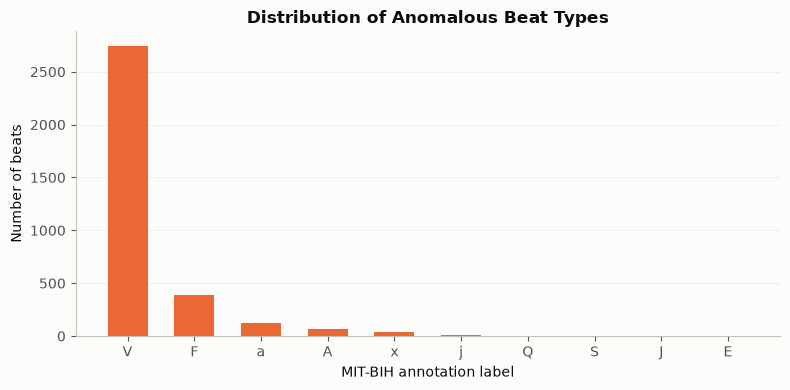

label
V    2745
F     384
a     119
A      68
x      37
j      10
Q       4
S       2
J       1
E       1


In [6]:
anomaly_counts = beats_df.loc[anomaly_mask, "label"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(anomaly_counts.index, anomaly_counts.values, color=COLOR_ANOMALY, width=0.6)
ax.set_title("Distribution of Anomalous Beat Types")
ax.set_xlabel("MIT-BIH annotation label")
ax.set_ylabel("Number of beats")
ax.grid(axis="y", alpha=0.6)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(anomaly_counts.to_string())

Anomalous is not one morphology: this database mixes several distinct beat types (ventricular ectopics, atrial premature beats, fusion beats, paced beats, ...) under a single normal-vs-anomalous split. That matters for the average-anomaly-beat comparisons later in this notebook, since averaging across sub-types can wash out a sub-type-specific pattern.

In [7]:
per_beat_stats = pd.DataFrame({
    "mean_amp": WINDOWS.mean(axis=1),
    "std_amp": WINDOWS.std(axis=1),
    "min_amp": WINDOWS.min(axis=1),
    "max_amp": WINDOWS.max(axis=1),
    "peak_to_peak": WINDOWS.max(axis=1) - WINDOWS.min(axis=1),
    "group": np.where(anomaly_mask, "anomalous", "normal"),
})
summary_table = per_beat_stats.groupby("group").describe().T
display(summary_table)

record_finding(
    section="1. Dataset Overview",
    observation=(
        f"{n_beats} beats loaded from {n_records_loaded} records; "
        f"{n_anomalous}/{n_beats} ({n_anomalous/n_beats:.1%}) anomalous, spread across "
        f"{beats_df.loc[anomaly_mask, 'label'].nunique()} distinct annotation labels "
        f"(dominant: {anomaly_counts.index[0]} with {anomaly_counts.iloc[0]} beats)."
    ),
    motivates_change="Confirms the class imbalance Quorum's bucketing already targets; "
                      "the multi-label anomaly mix is a caveat for any single average-anomaly "
                      "analysis below.",
    confidence="High -- direct counts from the loaded data.",
)

group                 anomalous        normal
mean_amp     count  3371.000000  16890.000000
             mean    980.805806    973.329956
             std      41.876961     44.874843
             min     680.177778    564.955556
             25%     974.622222    964.897222
             50%     990.000000    982.647222
             75%    1002.263889    997.272222
             max    1460.750000   1556.200000
std_amp      count  3371.000000  16890.000000
             mean    113.809594     61.586562
             std      51.036756     14.970693
             min       4.353146      8.029642
             25%      82.889971     50.277346
             50%     115.991499     59.870007
             75%     130.523363     71.195115
             max     243.240114    303.022281
min_amp      count  3371.000000  16890.000000
             mean    823.851379    920.193428
             std     105.660327     52.393588
             min     327.000000    456.000000
             25%     808.500000    904.000000
             50%     852.000000    929.000000
             75%     881.000000    954.000000
             max    1219.000000   1441.000000
max_amp      count  3371.000000  16890.000000
             mean   1282.805992   1281.531498
             std     121.938221     72.738573
             min     937.000000    702.000000
             25%    1214.000000   1223.000000
             50%    1285.000000   1276.000000
             75%    1386.000000   1328.000000
             max    1622.000000   1754.000000
peak_to_peak count  3371.000000  16890.000000
             mean    458.954613    361.338070
             std     187.351106     92.463650
             min      22.000000     35.000000
             25%     369.500000    289.000000
             50%     441.000000    352.000000
             75%     525.000000    444.000000
             max     917.000000    770.000000

## 2. Beat Visualization

Why: before touching any algorithm, it is worth just looking at the waveforms. Random samples show within-class variability (are normal beats all alike, or noisy?); the average plus/minus variance envelope shows where in the window normal and anomalous morphology actually diverge, which matters for feature grouping and window sizing later.

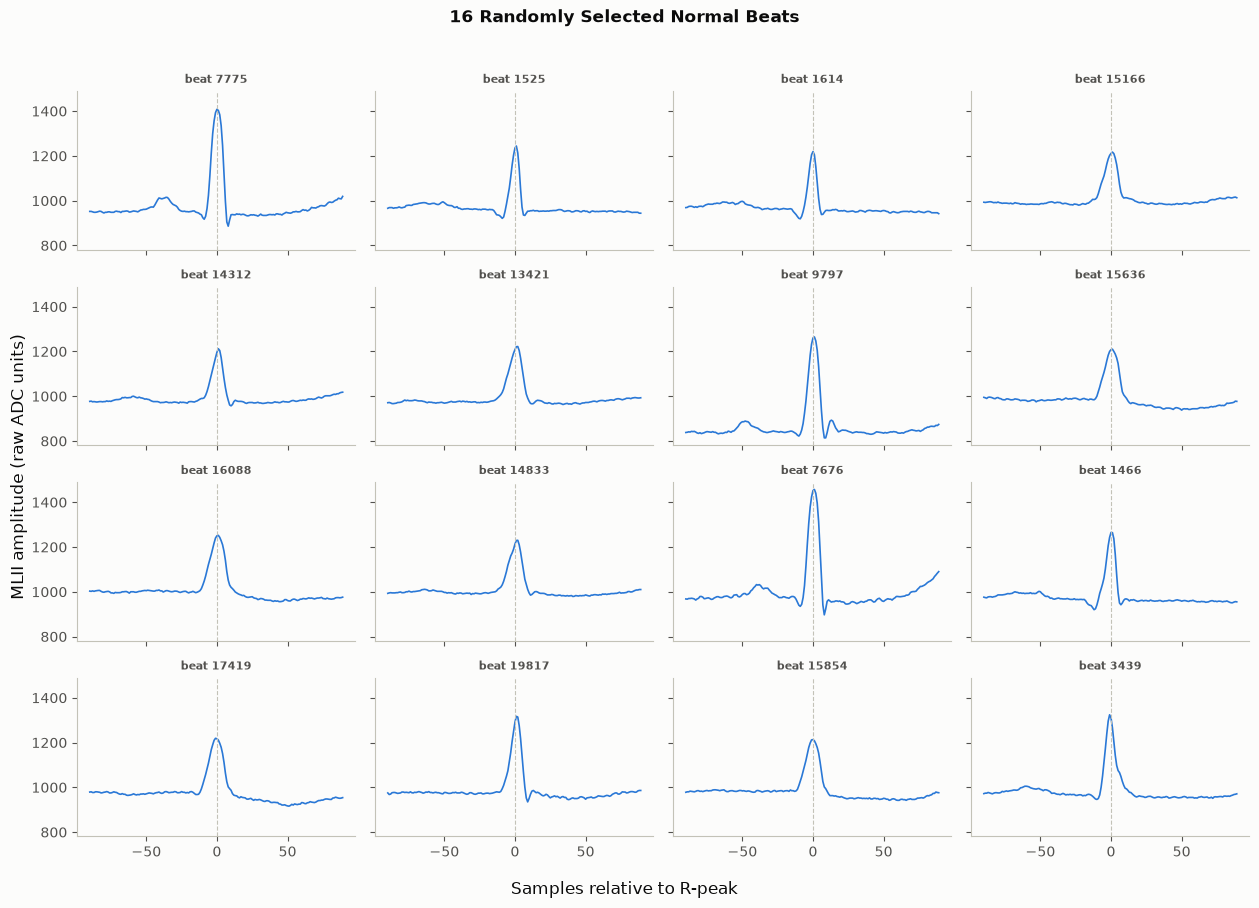

In [8]:
def plot_beat_grid(indices, windows, title, color, n_cols=4):
    n = len(indices)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.2 * n_rows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    t = np.arange(-WINDOW_HALF, WINDOW_HALF)
    for ax, idx in zip(axes, indices):
        ax.plot(t, windows[idx], color=color, linewidth=1.2)
        ax.axvline(0, color="#c3c2b7", linewidth=0.8, linestyle="--")
        ax.set_title(f"beat {idx}", fontsize=8, color="#52514e")
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title, y=1.02, fontsize=12, fontweight="bold")
    fig.supxlabel("Samples relative to R-peak")
    fig.supylabel("MLII amplitude (raw ADC units)")
    plt.tight_layout()
    plt.show()

normal_sample_idx = rng.choice(np.flatnonzero(normal_mask), size=16, replace=False)
plot_beat_grid(normal_sample_idx, WINDOWS, "16 Randomly Selected Normal Beats", COLOR_NORMAL)

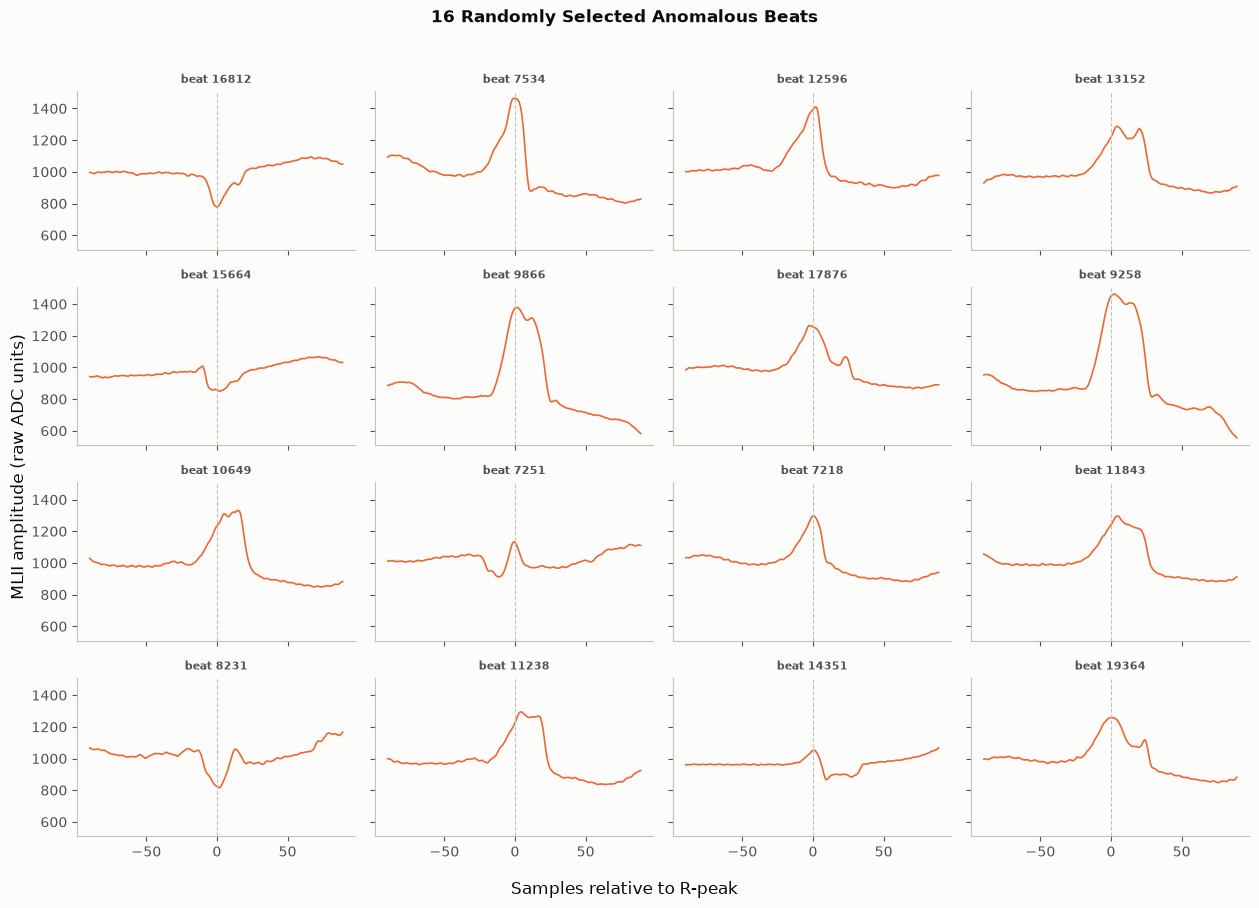

Labels in this sample:
label
V    15
F     1


In [9]:
anomaly_sample_idx = rng.choice(np.flatnonzero(anomaly_mask), size=16, replace=False)
plot_beat_grid(anomaly_sample_idx, WINDOWS, "16 Randomly Selected Anomalous Beats", COLOR_ANOMALY)
print("Labels in this sample:")
print(beats_df.loc[anomaly_sample_idx, "label"].value_counts().to_string())

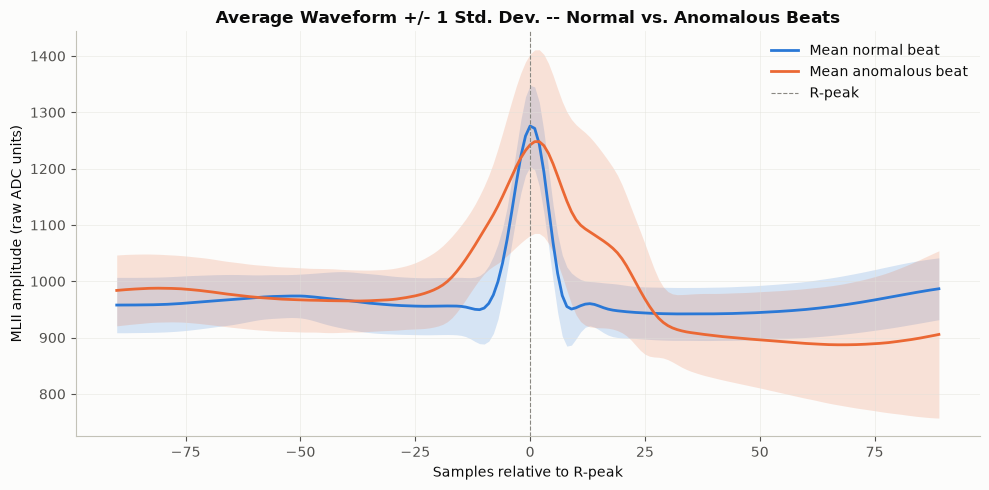

In [10]:
t = np.arange(-WINDOW_HALF, WINDOW_HALF)
mean_normal = WINDOWS[normal_mask].mean(axis=0)
std_normal = WINDOWS[normal_mask].std(axis=0)
mean_anomaly = WINDOWS[anomaly_mask].mean(axis=0)
std_anomaly = WINDOWS[anomaly_mask].std(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, mean_normal, color=COLOR_NORMAL, linewidth=2, label="Mean normal beat")
ax.fill_between(t, mean_normal - std_normal, mean_normal + std_normal, color=COLOR_NORMAL, alpha=0.18, linewidth=0)
ax.plot(t, mean_anomaly, color=COLOR_ANOMALY, linewidth=2, label="Mean anomalous beat")
ax.fill_between(t, mean_anomaly - std_anomaly, mean_anomaly + std_anomaly, color=COLOR_ANOMALY, alpha=0.18, linewidth=0)
ax.axvline(0, color="#898781", linewidth=0.8, linestyle="--", label="R-peak")
ax.set_title("Average Waveform +/- 1 Std. Dev. -- Normal vs. Anomalous Beats")
ax.set_xlabel("Samples relative to R-peak")
ax.set_ylabel("MLII amplitude (raw ADC units)")
ax.legend(frameon=False)
ax.grid(alpha=0.5)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

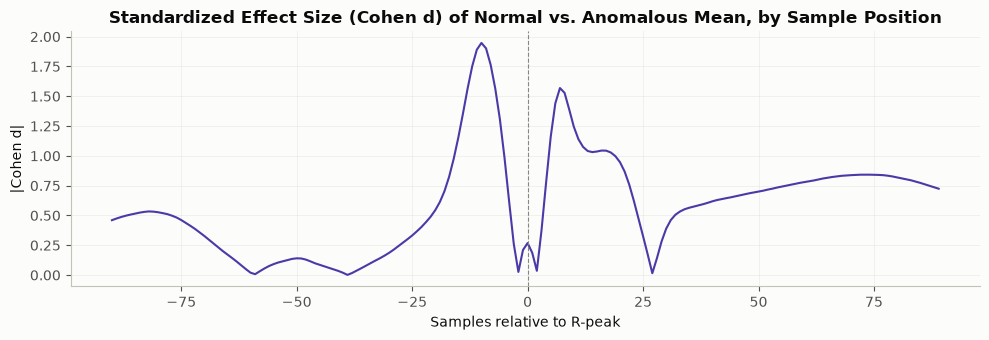

Largest normal/anomaly separation at offset -10 samples from the R-peak (|Cohen d| = 1.95).


In [11]:
mean_gap = np.abs(mean_anomaly - mean_normal)
pooled_std = np.sqrt((std_normal**2 + std_anomaly**2) / 2)
cohens_d = mean_gap / np.where(pooled_std == 0, np.nan, pooled_std)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t, cohens_d, color="#4a3aa7", linewidth=1.5)
ax.axvline(0, color="#898781", linewidth=0.8, linestyle="--")
ax.set_title("Standardized Effect Size (Cohen d) of Normal vs. Anomalous Mean, by Sample Position")
ax.set_xlabel("Samples relative to R-peak")
ax.set_ylabel("|Cohen d|")
ax.grid(alpha=0.5)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

peak_gap_offset = t[np.nanargmax(cohens_d)]
print(f"Largest normal/anomaly separation at offset {peak_gap_offset:+d} samples from the R-peak "
      f"(|Cohen d| = {np.nanmax(cohens_d):.2f}).")

record_finding(
    section="2. Beat Visualization",
    observation=(
        f"Mean waveforms diverge most strongly around offset {peak_gap_offset:+d} samples "
        f"from the R-peak; variance envelopes are visibly wider for anomalous beats across "
        f"most of the window."
    ),
    motivates_change="Discriminative morphology is not uniformly spread across the 180-sample "
                      "window -- supports weighting or grouping features by position rather than "
                      "treating all 180 samples as equally informative.",
    confidence="Medium -- based on aggregate mean/variance only; individual anomaly sub-types "
               "(V, A, F, ...) were not separated here and may peak at different offsets.",
)

## 3. RR Interval Analysis

Why: RR interval (time between consecutive R-peaks) is rhythm information that Quorum's default beat-window features do not use when `include_rr=False`, and even the `include_rr=True` path folds it into just one scalar per beat. If normal and anomalous beats sit on measurably different RR distributions, that is a rhythm-level signal that is orthogonal to per-beat morphology, and worth treating as a first-class temporal feature (or bucketing/grouping key) rather than an afterthought.

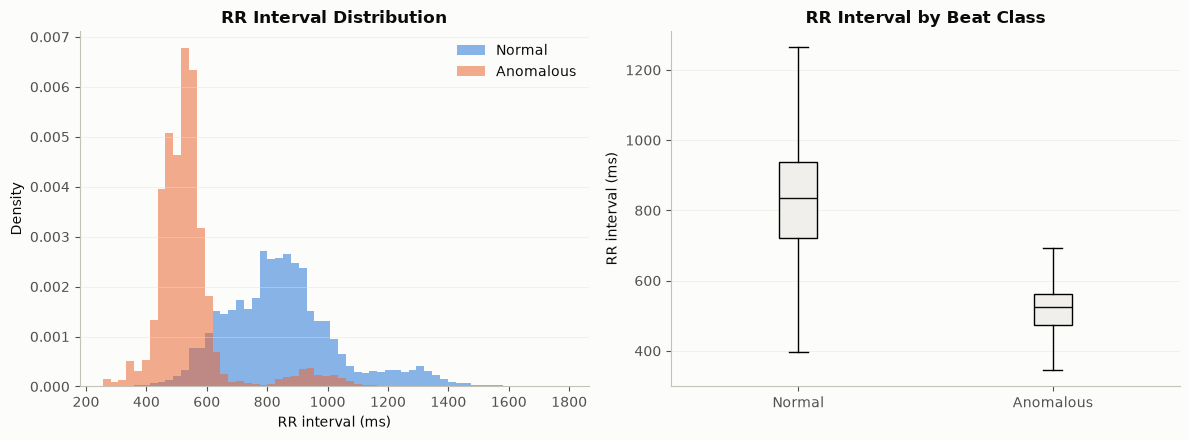

Normal RR:    median=836.1 ms, IQR=[722.2, 938.9]
Anomalous RR: median=525.0 ms, IQR=[475.0, 562.5]


In [12]:
beats_df["rr_prev_ms"] = beats_df["rr_prev"] / FS * 1000.0

rr_normal = beats_df.loc[normal_mask, "rr_prev_ms"].dropna()
rr_anomaly = beats_df.loc[anomaly_mask, "rr_prev_ms"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bins = np.linspace(
    beats_df["rr_prev_ms"].quantile(0.001), beats_df["rr_prev_ms"].quantile(0.999), 60
)
axes[0].hist(rr_normal, bins=bins, color=COLOR_NORMAL, alpha=0.55, label="Normal", density=True)
axes[0].hist(rr_anomaly, bins=bins, color=COLOR_ANOMALY, alpha=0.55, label="Anomalous", density=True)
axes[0].set_title("RR Interval Distribution")
axes[0].set_xlabel("RR interval (ms)")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

axes[1].boxplot([rr_normal, rr_anomaly], tick_labels=["Normal", "Anomalous"], showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor="#f0efec"), medianprops=dict(color="#0b0b0b"))
axes[1].set_title("RR Interval by Beat Class")
axes[1].set_ylabel("RR interval (ms)")

for ax in axes:
    ax.grid(axis="y", alpha=0.5)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Normal RR:    median={rr_normal.median():.1f} ms, IQR=[{rr_normal.quantile(.25):.1f}, {rr_normal.quantile(.75):.1f}]")
print(f"Anomalous RR: median={rr_anomaly.median():.1f} ms, IQR=[{rr_anomaly.quantile(.25):.1f}, {rr_anomaly.quantile(.75):.1f}]")

In [13]:
u_stat, u_pval = stats.mannwhitneyu(rr_normal, rr_anomaly, alternative="two-sided")
print(f"Mann-Whitney U test (normal vs. anomalous RR): U={u_stat:.3e}, p={u_pval:.3e}")

Mann-Whitney U test (normal vs. anomalous RR): U=5.274e+07, p=0.000e+00


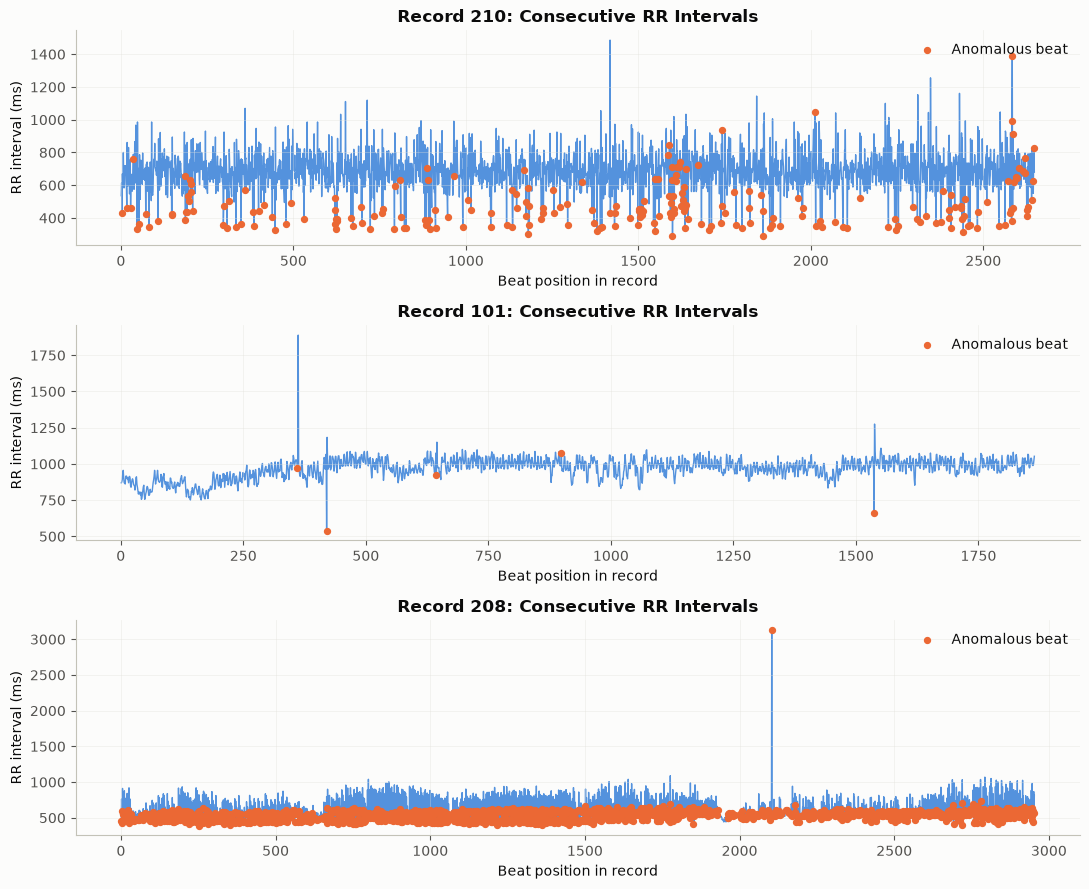

In [14]:
example_records = beats_df["record_id"].drop_duplicates().sample(
    n=min(3, beats_df["record_id"].nunique()), random_state=RANDOM_SEED
)

fig, axes = plt.subplots(len(example_records), 1, figsize=(11, 3 * len(example_records)), sharex=False)
axes = np.atleast_1d(axes)
for ax, rid in zip(axes, example_records):
    rec = beats_df[beats_df["record_id"] == rid].sort_values("beat_pos")
    ax.plot(rec["beat_pos"], rec["rr_prev_ms"], color=COLOR_NORMAL, linewidth=1, alpha=0.8, zorder=1)
    anomalous_rec = rec[rec["is_anomaly"]]
    ax.scatter(anomalous_rec["beat_pos"], anomalous_rec["rr_prev_ms"], color=COLOR_ANOMALY, s=18,
               zorder=2, label="Anomalous beat")
    ax.set_title(f"Record {rid}: Consecutive RR Intervals")
    ax.set_xlabel("Beat position in record")
    ax.set_ylabel("RR interval (ms)")
    ax.legend(frameon=False, loc="upper right")
    ax.grid(alpha=0.4)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [15]:
record_finding(
    section="3. RR Interval Analysis",
    observation=(
        f"Normal median RR = {rr_normal.median():.1f} ms vs. anomalous median RR = "
        f"{rr_anomaly.median():.1f} ms (Mann-Whitney p={u_pval:.2e}); RR sequences also show "
        f"visibly clustered runs of anomalous beats rather than uniform scattering."
    ),
    motivates_change="RR interval carries a statistically significant, and visually clustered, "
                      "rhythm signal beyond per-beat morphology -- supports treating RR (or local "
                      "RR context) as its own temporal grouping/bucketing key rather than a single "
                      "appended scalar.",
    confidence="High for the distributional difference (large n, significant test); medium for "
               "how well the clustering pattern generalizes beyond the records plotted.",
)

## 4. Autocorrelation Analysis

Why: autocorrelation shows how far, in samples, a beat predicts its own future/past waveform. If strong autocorrelation only extends to lag L, then features more than L samples apart inside the window are close to independent -- useful for deciding how large a contiguous feature group should be (see Section 5) and for sanity-checking the 180-sample window length (Section 8).

In [16]:
def autocorrelation(x, max_lag):
    """
    Normalized sample autocorrelation function, lags 0..max_lag. Uses the same
    denominator (sum of squared deviations) at every lag, which is the standard
    ACF convention used by e.g. statsmodels' default and Box & Jenkins.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.sum(x ** 2)
    if denom == 0:
        return np.zeros(max_lag + 1)
    n = len(x)
    return np.array([np.sum(x[:n - lag] * x[lag:]) / denom for lag in range(max_lag + 1)])

MAX_LAG = WINDOW_HALF  # half the window length is already a generous lag range here
lags = np.arange(MAX_LAG + 1)

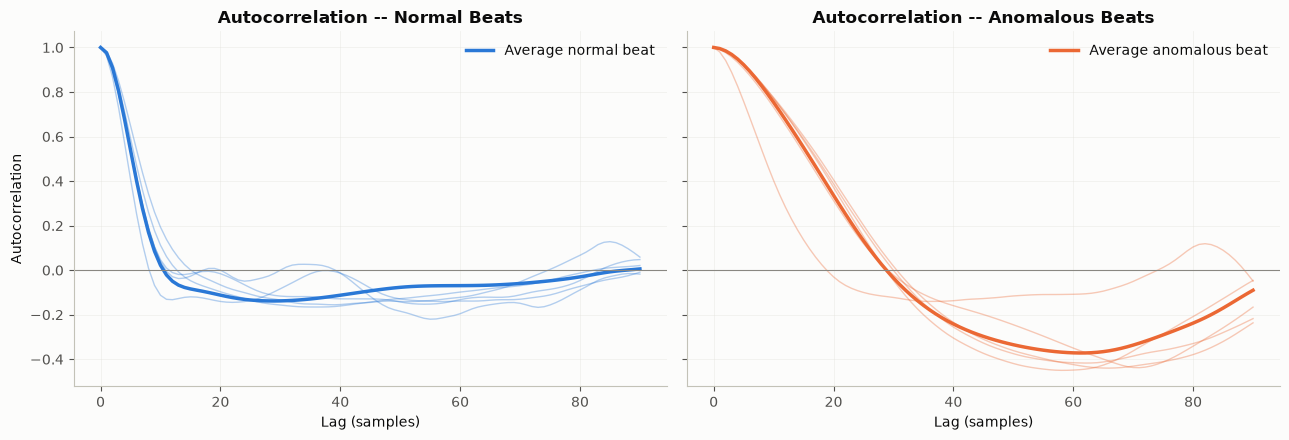

In [17]:
n_example = 5
example_normal_idx = rng.choice(np.flatnonzero(normal_mask), size=n_example, replace=False)
example_anomaly_idx = rng.choice(np.flatnonzero(anomaly_mask), size=n_example, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for idx in example_normal_idx:
    axes[0].plot(lags, autocorrelation(WINDOWS[idx], MAX_LAG), color=COLOR_NORMAL, alpha=0.35, linewidth=1)
axes[0].plot(lags, autocorrelation(mean_normal, MAX_LAG), color=COLOR_NORMAL, linewidth=2.5,
             label="Average normal beat")
axes[0].set_title("Autocorrelation -- Normal Beats")
axes[0].set_xlabel("Lag (samples)")
axes[0].set_ylabel("Autocorrelation")
axes[0].legend(frameon=False)

for idx in example_anomaly_idx:
    axes[1].plot(lags, autocorrelation(WINDOWS[idx], MAX_LAG), color=COLOR_ANOMALY, alpha=0.35, linewidth=1)
axes[1].plot(lags, autocorrelation(mean_anomaly, MAX_LAG), color=COLOR_ANOMALY, linewidth=2.5,
             label="Average anomalous beat")
axes[1].set_title("Autocorrelation -- Anomalous Beats")
axes[1].set_xlabel("Lag (samples)")
axes[1].legend(frameon=False)

for ax in axes:
    ax.axhline(0, color="#898781", linewidth=0.8)
    ax.grid(alpha=0.4)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
acf_normal_avg = autocorrelation(mean_normal, MAX_LAG)
acf_anomaly_avg = autocorrelation(mean_anomaly, MAX_LAG)

def dominant_lags(acf, n_peaks=3, min_lag=3):
    peaks, _ = find_peaks(acf[min_lag:])
    peaks = peaks + min_lag
    peaks = sorted(peaks, key=lambda p: acf[p], reverse=True)[:n_peaks]
    return [(int(p), float(acf[p])) for p in peaks]

peaks_normal = dominant_lags(acf_normal_avg)
peaks_anomaly = dominant_lags(acf_anomaly_avg)
print("Dominant lags, average normal beat  :", peaks_normal)
print("Dominant lags, average anomaly beat :", peaks_anomaly)

# First lag at which autocorrelation decays below 0.5, per average waveform
decay_normal = int(np.argmax(acf_normal_avg < 0.5))
decay_anomaly = int(np.argmax(acf_anomaly_avg < 0.5))
print(f"\nLag at which ACF first drops below 0.5: normal={decay_normal} samples, anomaly={decay_anomaly} samples")

Dominant lags, average normal beat  : []
Dominant lags, average anomaly beat : []

Lag at which ACF first drops below 0.5: normal=6 samples, anomaly=17 samples


**Reading the lags.** A short decay lag means adjacent raw-signal samples inside that span are largely redundant with each other -- a feature-selection scheme that treats every one of the 180 samples as an independent axis (uniform random selection) is spending encoding capacity on correlated information within that span. Secondary ACF peaks away from lag 0 typically correspond to the spacing between the R-peak and the next repeating structure in the waveform (e.g. the T-wave); a peak there is a natural candidate boundary for a feature group or a temporal bucket, rather than an arbitrary stride.

In [19]:
record_finding(
    section="4. Autocorrelation Analysis",
    observation=(
        f"Average-waveform ACF drops below 0.5 by lag {decay_normal} samples (normal) / "
        f"{decay_anomaly} samples (anomaly); dominant secondary peaks at {peaks_normal} "
        f"(normal) vs. {peaks_anomaly} (anomaly)."
    ),
    motivates_change="Strong short-range autocorrelation means adjacent raw-signal samples are "
                      "largely redundant -- a feature-grouping scheme that treats every sample as "
                      "independent (as random per-feature selection does) is spending encoding "
                      "capacity on correlated information; coarser blocks near the decay lag would "
                      "not lose much information.",
    confidence="Medium -- based on average waveforms and a handful of individual-beat examples, "
               "not the full per-beat ACF distribution.",
)

## 5. Correlation Analysis

Why: this asks the same redundancy question as autocorrelation, but directly and across the whole dataset rather than within single beats -- which time positions in the 180-sample window move together across beats? Quorum's `feature_selection.py` already has a temporal strategy (`'f'`) that stripes across the full feature axis specifically because a contiguous block of adjacent samples is assumed to be nearly redundant. This section checks that assumption directly and looks for which regions are most redundant, rather than assuming uniform redundancy.

In [20]:
pearson_corr = np.corrcoef(WINDOWS, rowvar=False)  # shape (WINDOW_LEN, WINDOW_LEN)
spearman_corr, _ = stats.spearmanr(WINDOWS, axis=0)  # same shape

print(f"Pearson corr matrix shape : {pearson_corr.shape}")
print(f"Spearman corr matrix shape: {spearman_corr.shape}")

Pearson corr matrix shape : (180, 180)
Spearman corr matrix shape: (180, 180)


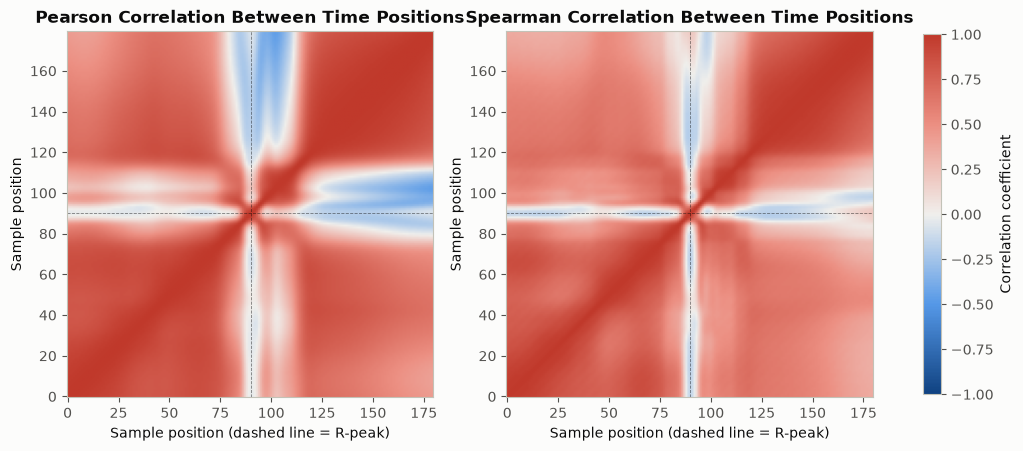

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, mat, name in zip(axes, [pearson_corr, spearman_corr], ["Pearson", "Spearman"]):
    im = ax.imshow(mat, cmap=DIVERGING_CMAP, vmin=-1, vmax=1, origin="lower")
    ax.axvline(WINDOW_HALF, color="#0b0b0b", linewidth=0.6, linestyle="--", alpha=0.5)
    ax.axhline(WINDOW_HALF, color="#0b0b0b", linewidth=0.6, linestyle="--", alpha=0.5)
    ax.set_title(f"{name} Correlation Between Time Positions")
    ax.set_xlabel("Sample position (dashed line = R-peak)")
    ax.set_ylabel("Sample position")
fig.colorbar(im, ax=axes, shrink=0.85, label="Correlation coefficient")
plt.show()

Both heatmaps should show a bright block along the diagonal (neighboring positions are highly correlated) that fades with distance, plus off-diagonal structure wherever the QRS complex and the T-wave co-vary. The next cell turns that visual pattern into an explicit list of contiguous high-correlation blocks.

In [22]:
def find_high_correlation_blocks(corr_matrix, threshold=0.9, min_length=3):
    """
    Flag contiguous runs of adjacent time positions (i, i+1) whose Pearson
    correlation stays above threshold, then merge consecutive flagged positions
    into blocks. This is a direct, easily-audited stand-in for identifying
    regions that could be selected together during feature selection -- no
    external clustering library, just adjacency, a threshold, and run-length
    merging.
    """
    n = corr_matrix.shape[0]
    adjacent_corr = np.array([corr_matrix[i, i + 1] for i in range(n - 1)])
    is_high = adjacent_corr >= threshold

    blocks = []
    start = None
    for i, flag in enumerate(is_high):
        if flag and start is None:
            start = i
        elif not flag and start is not None:
            if i - start + 1 >= min_length:
                blocks.append((start, i))
            start = None
    if start is not None and n - 1 - start + 1 >= min_length:
        blocks.append((start, n - 1))
    return adjacent_corr, blocks

adjacent_corr, high_corr_blocks = find_high_correlation_blocks(pearson_corr, threshold=0.9, min_length=3)

print(f"Found {len(high_corr_blocks)} contiguous blocks with adjacent Pearson correlation >= 0.9:")
for s, e in high_corr_blocks:
    print(f"  samples [{s - WINDOW_HALF:+d}, {e - WINDOW_HALF:+d}] relative to R-peak  (length {e - s + 1})")

Found 1 contiguous blocks with adjacent Pearson correlation >= 0.9:
  samples [-90, +89] relative to R-peak  (length 180)


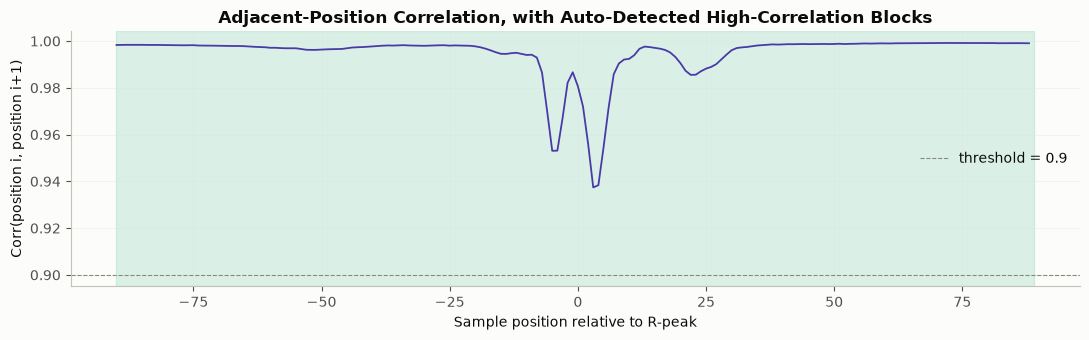

In [23]:
fig, ax = plt.subplots(figsize=(11, 3.5))
t_full = np.arange(WINDOW_LEN - 1) - WINDOW_HALF
ax.plot(t_full, adjacent_corr, color="#4a3aa7", linewidth=1.3)
ax.axhline(0.9, color="#898781", linewidth=0.8, linestyle="--", label="threshold = 0.9")
for s, e in high_corr_blocks:
    ax.axvspan(s - WINDOW_HALF, e - WINDOW_HALF, color=COLOR_MIXED, alpha=0.15)
ax.set_title("Adjacent-Position Correlation, with Auto-Detected High-Correlation Blocks")
ax.set_xlabel("Sample position relative to R-peak")
ax.set_ylabel("Corr(position i, position i+1)")
ax.legend(frameon=False)
ax.grid(alpha=0.4)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
total_blocked_samples = sum(e - s + 1 for s, e in high_corr_blocks)
record_finding(
    section="5. Correlation Analysis",
    observation=(
        f"{len(high_corr_blocks)} contiguous blocks of adjacent-position Pearson correlation "
        f">= 0.9 were found, covering {total_blocked_samples}/{WINDOW_LEN} "
        f"({total_blocked_samples / WINDOW_LEN:.0%}) of the window; Pearson and Spearman "
        f"heatmaps show the same qualitative block structure."
    ),
    motivates_change="A meaningful fraction of the window is made of near-redundant contiguous "
                      "positions -- consistent with feature_selection.py strategy 'f' avoiding a "
                      "single contiguous block, and suggests feature groups could be built directly "
                      "from these detected blocks (one representative feature per block) rather "
                      "than from evenly-spaced striding or fully random selection.",
    confidence="High for the correlation structure itself (computed on the full loaded dataset); "
               "medium for whether 0.9 is the right threshold for a feature-grouping design.",
)

## 6. Dynamic Time Warping Analysis

Why: beats are already R-peak aligned by construction, so much of what DTW would normally fix (gross misalignment) is already handled. What is left is local timing variation -- QRS complexes that are narrower or wider, or T-waves that sit closer to or farther from the R-peak -- which Euclidean distance penalizes just for being offset in time, even when the underlying morphology is similar. If DTW distance separates normal from anomalous beats more cleanly than Euclidean distance on the same pairs, that is a concrete argument for a DTW-aware distance or bucketing step somewhere in Quorum's pipeline.

**Cost note.** DTW is O(n*m) per pair (here n=m=180, reduced by a Sakoe-Chiba band below). Computing a full pairwise matrix over the whole dataset is not tractable in a notebook, so this section works on a fixed-size balanced random subsample (`N_DTW_PER_CLASS` beats per class) instead of the full dataset. This is standard practice for exploratory DTW distance-matrix analysis.

In [25]:
def dtw_distance(x, y, band_radius=None, return_path=False):
    """
    Classic DTW (Sakoe & Chiba, 1978) via dynamic programming, absolute-value
    local cost. band_radius, if set, restricts warping to a band around the
    diagonal -- keeps the pairwise matrices below tractable and avoids
    pathological warps between unrelated parts of two beats that are already
    roughly R-peak aligned.
    """
    n, m = len(x), len(y)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0

    for i in range(1, n + 1):
        j_lo = 1 if band_radius is None else max(1, i - band_radius)
        j_hi = m if band_radius is None else min(m, i + band_radius)
        row_prev = D[i - 1]
        row_cur = D[i]
        for j in range(j_lo, j_hi + 1):
            cost = abs(x[i - 1] - y[j - 1])
            row_cur[j] = cost + min(row_prev[j], row_cur[j - 1], row_prev[j - 1])

    distance = D[n, m]
    if not return_path:
        return distance

    path = []
    i, j = n, m
    while (i, j) != (0, 0):
        path.append((i - 1, j - 1))
        candidates = {}
        if i > 0 and j > 0:
            candidates[(i - 1, j - 1)] = D[i - 1, j - 1]
        if i > 0:
            candidates[(i - 1, j)] = D[i - 1, j]
        if j > 0:
            candidates[(i, j - 1)] = D[i, j - 1]
        i, j = min(candidates, key=candidates.get)
    path.reverse()
    return distance, path

DTW_BAND = 20  # samples; about 11% of the 180-sample window

In [26]:
N_DTW_PER_CLASS = 30  # keeps the ~n^2/2 pairwise DTW computation tractable

dtw_normal_idx = rng.choice(np.flatnonzero(normal_mask), size=N_DTW_PER_CLASS, replace=False)
dtw_anomaly_idx = rng.choice(np.flatnonzero(anomaly_mask), size=N_DTW_PER_CLASS, replace=False)
dtw_sample_idx = np.concatenate([dtw_normal_idx, dtw_anomaly_idx])
dtw_sample_is_anomaly = beats_df["is_anomaly"].values[dtw_sample_idx]
dtw_sample_windows = WINDOWS[dtw_sample_idx]

n_dtw = len(dtw_sample_idx)
dtw_dist = np.zeros((n_dtw, n_dtw))
euc_dist = np.zeros((n_dtw, n_dtw))

for a in range(n_dtw):
    for b in range(a + 1, n_dtw):
        d = dtw_distance(dtw_sample_windows[a], dtw_sample_windows[b], band_radius=DTW_BAND)
        e = np.linalg.norm(dtw_sample_windows[a] - dtw_sample_windows[b])
        dtw_dist[a, b] = dtw_dist[b, a] = d
        euc_dist[a, b] = euc_dist[b, a] = e

n_pairs = n_dtw * (n_dtw - 1) // 2
print(f"Computed DTW + Euclidean distances for {n_dtw} beats ({n_pairs} pairs). "
      f"This cell may take roughly a minute or two; lower N_DTW_PER_CLASS to speed it up.")

Computed DTW + Euclidean distances for 60 beats (1770 pairs). This cell may take roughly a minute or two; lower N_DTW_PER_CLASS to speed it up.


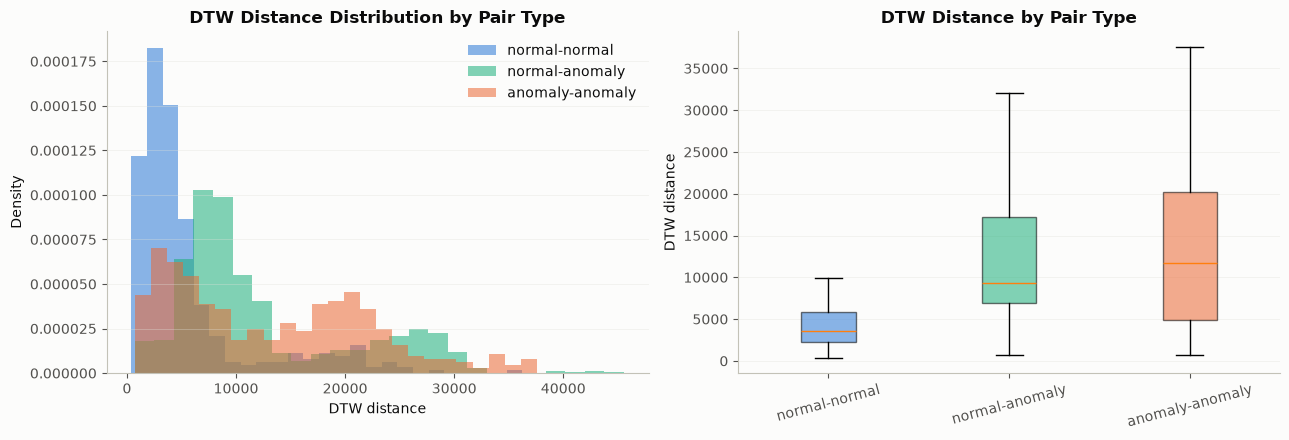

                 count          mean          std    min     25%      50%  \
pair_type                                                                   
anomaly-anomaly  435.0  13223.308046  9092.149065  735.0  4921.5  11660.0   
normal-anomaly   900.0  12479.975556  8232.761286  715.0  6866.5   9274.5   
normal-normal    435.0   5523.498851  5686.979585  395.0  2230.5   3604.0   

                     75%      max  
pair_type                          
anomaly-anomaly  20221.5  37575.0  
normal-anomaly   17189.5  45555.0  
normal-normal     5793.0  36259.0  


In [27]:
iu = np.triu_indices(n_dtw, k=1)
label_i = dtw_sample_is_anomaly[iu[0]]
label_j = dtw_sample_is_anomaly[iu[1]]
pair_type = np.where(~label_i & ~label_j, "normal-normal",
             np.where(label_i & label_j, "anomaly-anomaly", "normal-anomaly"))

dtw_pairs_df = pd.DataFrame({
    "pair_type": pair_type,
    "dtw_distance": dtw_dist[iu],
    "euclidean_distance": euc_dist[iu],
})

PAIR_TYPES = ["normal-normal", "normal-anomaly", "anomaly-anomaly"]
PAIR_COLORS = [COLOR_NORMAL, COLOR_MIXED, COLOR_ANOMALY]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ptype, color in zip(PAIR_TYPES, PAIR_COLORS):
    subset = dtw_pairs_df.loc[dtw_pairs_df.pair_type == ptype, "dtw_distance"]
    axes[0].hist(subset, bins=25, alpha=0.55, label=ptype, color=color, density=True)
axes[0].set_title("DTW Distance Distribution by Pair Type")
axes[0].set_xlabel("DTW distance")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

data_by_type = [dtw_pairs_df.loc[dtw_pairs_df.pair_type == t, "dtw_distance"] for t in PAIR_TYPES]
bp = axes[1].boxplot(data_by_type, tick_labels=PAIR_TYPES, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], PAIR_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
axes[1].set_title("DTW Distance by Pair Type")
axes[1].set_ylabel("DTW distance")
axes[1].tick_params(axis="x", rotation=15)

for ax in axes:
    ax.grid(axis="y", alpha=0.4)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(dtw_pairs_df.groupby("pair_type")["dtw_distance"].describe())

The next cell draws the single closest pair within each pair-type category and overlays the DTW warping path between them, so the alignment itself -- not just the summary distance -- is visible.

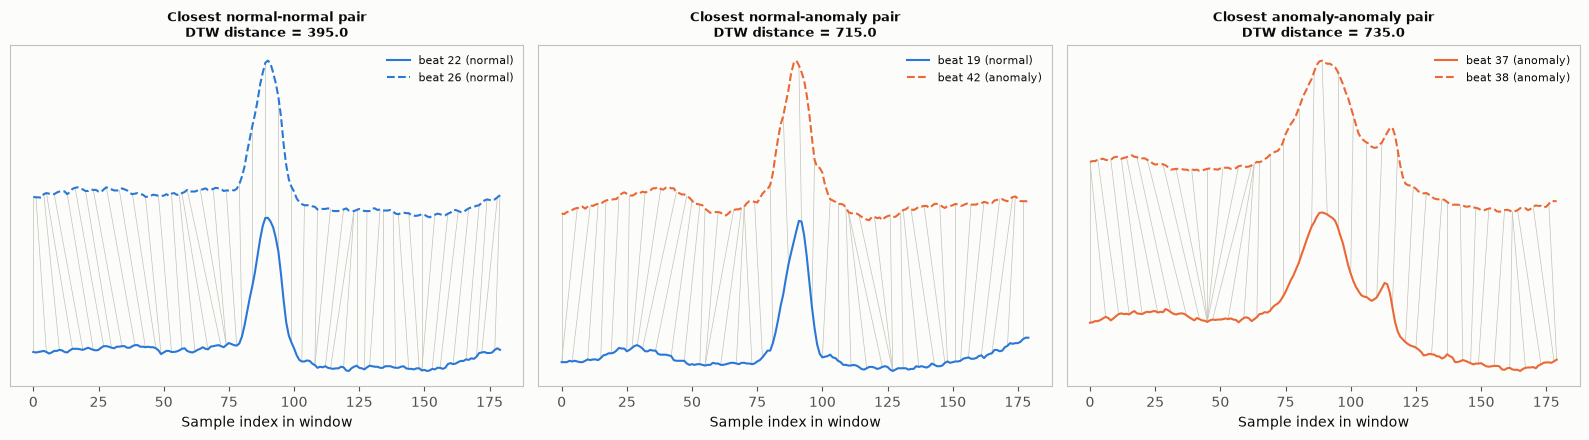

In [28]:
def plot_dtw_alignment(idx_a, idx_b, windows, label_a, label_b, ax, band_radius=DTW_BAND):
    x, y = windows[idx_a], windows[idx_b]
    dist, path = dtw_distance(x, y, band_radius=band_radius, return_path=True)
    offset = (np.max(x) - np.min(y)) + 1.0  # vertical shift so the two traces do not overlap
    t_idx = np.arange(len(x))
    color_a = COLOR_ANOMALY if label_a else COLOR_NORMAL
    color_b = COLOR_ANOMALY if label_b else COLOR_NORMAL
    ax.plot(t_idx, x, color=color_a, linewidth=1.5,
            label=f"beat {idx_a} ({'anomaly' if label_a else 'normal'})")
    ax.plot(t_idx, y + offset, color=color_b, linewidth=1.5, linestyle="--",
            label=f"beat {idx_b} ({'anomaly' if label_b else 'normal'})")
    step = max(1, len(path) // 40)  # thin the path lines so the plot stays legible
    for i, j in path[::step]:
        ax.plot([t_idx[i], t_idx[j]], [x[i], y[j] + offset], color="#c3c2b7", linewidth=0.5, zorder=0)
    ax.set_title(f"DTW distance = {dist:.1f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    ax.set_xlabel("Sample index in window")
    ax.set_yticks([])

def closest_pair(mask):
    sub_dist = np.where(mask, dtw_dist, np.inf)
    np.fill_diagonal(sub_dist, np.inf)
    a, b = np.unravel_index(np.argmin(sub_dist), sub_dist.shape)
    return a, b

nn_mask = np.outer(~dtw_sample_is_anomaly, ~dtw_sample_is_anomaly)
aa_mask = np.outer(dtw_sample_is_anomaly, dtw_sample_is_anomaly)
na_mask = (np.outer(~dtw_sample_is_anomaly, dtw_sample_is_anomaly) |
           np.outer(dtw_sample_is_anomaly, ~dtw_sample_is_anomaly))

pairs_to_plot = [closest_pair(nn_mask), closest_pair(na_mask), closest_pair(aa_mask)]
titles = ["Closest normal-normal pair", "Closest normal-anomaly pair", "Closest anomaly-anomaly pair"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (a, b), title in zip(axes, pairs_to_plot, titles):
    plot_dtw_alignment(a, b, dtw_sample_windows, dtw_sample_is_anomaly[a], dtw_sample_is_anomaly[b], ax)
    ax.set_title(f"{title}\n" + ax.get_title(), fontsize=9)
plt.tight_layout()
plt.show()

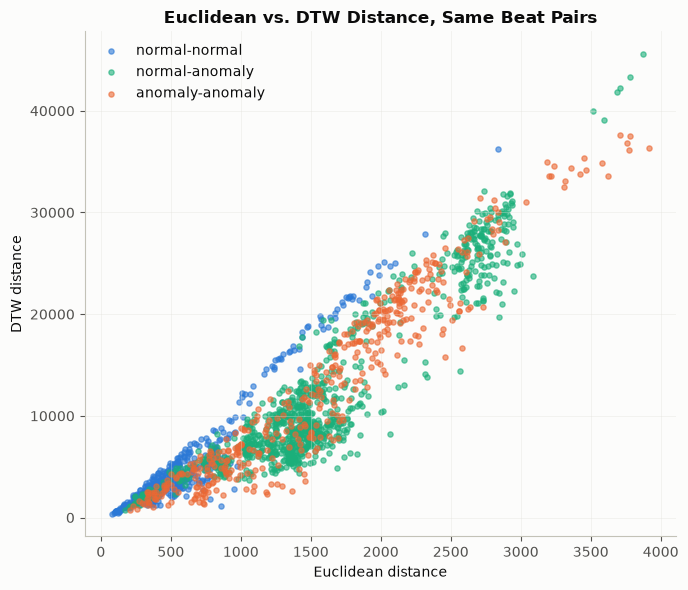

Correlation between Euclidean and DTW distance across all sampled pairs: 0.932
Separation ratio (mean normal-anomaly distance / mean within-class distance):
  Euclidean: 1.469
  DTW      : 1.331
(ratio > 1 means cross-class pairs are, on average, farther apart than same-class pairs)


In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
for ptype, color in zip(PAIR_TYPES, PAIR_COLORS):
    subset = dtw_pairs_df[dtw_pairs_df.pair_type == ptype]
    ax.scatter(subset["euclidean_distance"], subset["dtw_distance"], s=14, alpha=0.6, color=color, label=ptype)
ax.set_title("Euclidean vs. DTW Distance, Same Beat Pairs")
ax.set_xlabel("Euclidean distance")
ax.set_ylabel("DTW distance")
ax.legend(frameon=False)
ax.grid(alpha=0.4)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

corr_euc_dtw = np.corrcoef(dtw_pairs_df["euclidean_distance"], dtw_pairs_df["dtw_distance"])[0, 1]
print(f"Correlation between Euclidean and DTW distance across all sampled pairs: {corr_euc_dtw:.3f}")

def separation_ratio(df, metric):
    within = df.loc[df.pair_type.isin(["normal-normal", "anomaly-anomaly"]), metric].mean()
    between = df.loc[df.pair_type == "normal-anomaly", metric].mean()
    return between / within

sep_euclidean = separation_ratio(dtw_pairs_df, "euclidean_distance")
sep_dtw = separation_ratio(dtw_pairs_df, "dtw_distance")
print("Separation ratio (mean normal-anomaly distance / mean within-class distance):")
print(f"  Euclidean: {sep_euclidean:.3f}")
print(f"  DTW      : {sep_dtw:.3f}")
print("(ratio > 1 means cross-class pairs are, on average, farther apart than same-class pairs)")

In [30]:
dtw_favors_separation = sep_dtw > sep_euclidean
record_finding(
    section="6. DTW Analysis",
    observation=(
        f"Across {n_pairs} sampled pairs, Euclidean/DTW distance correlate at r={corr_euc_dtw:.2f}; "
        f"separation ratio (cross-class / within-class mean distance) is {sep_euclidean:.2f} for "
        f"Euclidean vs. {sep_dtw:.2f} for DTW."
    ),
    motivates_change=(
        "DTW gives a more favorable class-separation ratio than Euclidean on this sample -- "
        "supports exploring a DTW-aware distance or grouping step; the effect size should be "
        "treated as a first read, not a final result."
        if dtw_favors_separation else
        "DTW does not separate classes noticeably better than plain Euclidean distance on this "
        "sample -- less evidence here that DTW would improve Quorum's bucketing/distance choices "
        "beyond what Euclidean already captures."
    ),
    confidence=f"Medium -- based on a random {N_DTW_PER_CLASS}-per-class subsample (not the full "
               f"dataset) with a fixed Sakoe-Chiba band of {DTW_BAND} samples.",
)

## 7. Similarity Structure

Why: Quorum currently buckets beats either by uniform random shuffling (`create_data_buckets`) or by raw time order (`create_temporal_buckets`). Neither looks at beat similarity directly. This section checks, using the DTW distance matrix from Section 6, whether anomalous beats naturally form their own similarity cluster(s) -- if they do, a similarity-informed bucketing scheme becomes a plausible alternative worth prototyping later.

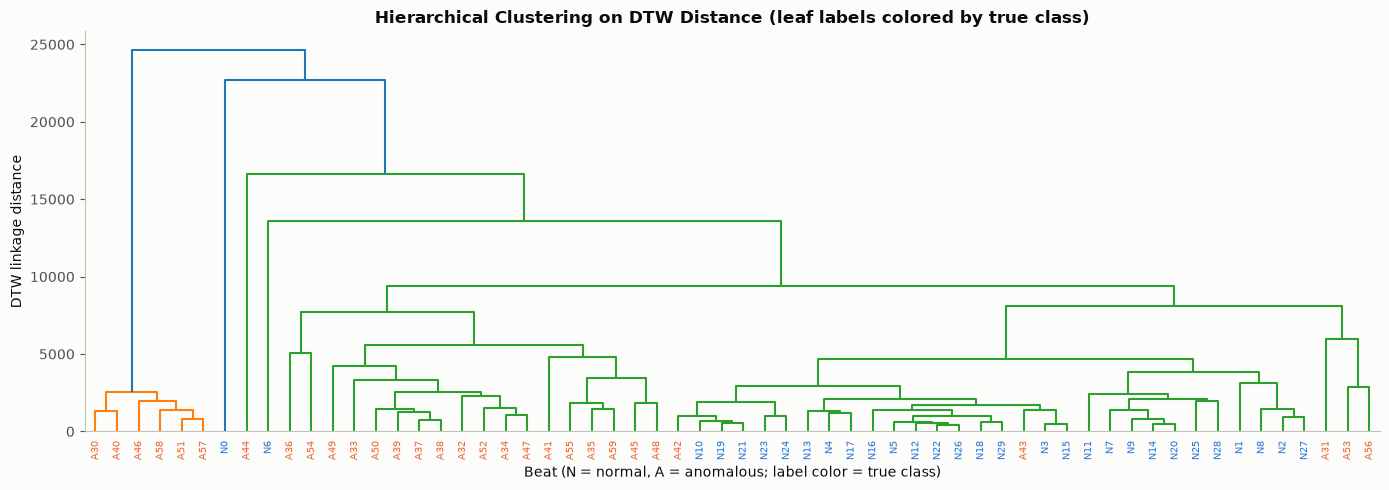

In [31]:
condensed = squareform(dtw_dist, checks=False)
Z = linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(14, 5))
leaf_labels = [f"{'A' if a else 'N'}{i}" for i, a in enumerate(dtw_sample_is_anomaly)]
dendro = dendrogram(Z, ax=ax, labels=leaf_labels, leaf_rotation=90, leaf_font_size=7)

# Recolor leaf tick labels by true class (blue=normal, orange=anomalous) --
# dendrogram() colors links, not labels, by default, and here we want the
# ground-truth class overlaid on top of the unsupervised tree structure.
for tick_label, leaf_idx in zip(ax.get_xticklabels(), dendro["leaves"]):
    tick_label.set_color(COLOR_ANOMALY if dtw_sample_is_anomaly[leaf_idx] else COLOR_NORMAL)

ax.set_title("Hierarchical Clustering on DTW Distance (leaf labels colored by true class)")
ax.set_xlabel("Beat (N = normal, A = anomalous; label color = true class)")
ax.set_ylabel("DTW linkage distance")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [32]:
for k in (2, 3, 4):
    cluster_ids = fcluster(Z, t=k, criterion="maxclust")
    crosstab = pd.crosstab(cluster_ids, np.where(dtw_sample_is_anomaly, "anomalous", "normal"))
    print(f"\n--- k={k} clusters ---")
    print(crosstab)


--- k=2 clusters ---
col_0  anomalous  normal
row_0                   
1              6       0
2             24      30

--- k=3 clusters ---
col_0  anomalous  normal
row_0                   
1              6       0
2             24      29
3              0       1

--- k=4 clusters ---
col_0  anomalous  normal
row_0                   
1              6       0
2             23      29
3              1       0
4              0       1


In [33]:
cluster_ids_k2 = fcluster(Z, t=2, criterion="maxclust")
cluster_df = pd.DataFrame({"cluster": cluster_ids_k2, "is_anomaly": dtw_sample_is_anomaly})
purity_per_cluster = cluster_df.groupby("cluster")["is_anomaly"].agg(["mean", "count"])
print(purity_per_cluster)

overall_majority_purity = (
    cluster_df.groupby("cluster")["is_anomaly"].apply(lambda s: max(s.mean(), 1 - s.mean()))
).mean()

clusters_beat_chance = overall_majority_purity > 0.65
record_finding(
    section="7. Similarity Structure",
    observation=(
        f"At k=2, DTW-based hierarchical clusters have average majority-class purity "
        f"{overall_majority_purity:.1%} (chance level on this balanced subsample is 50%)."
    ),
    motivates_change=(
        "DTW-based clusters separate normal from anomalous beats noticeably better than chance "
        "on this subsample -- worth prototyping a DTW-similarity-informed bucketing scheme."
        if clusters_beat_chance else
        "DTW-based clusters do not separate normal from anomalous beats much better than chance "
        "here -- similarity-informed bucketing would need a stronger distance or feature choice "
        "to be worth the added complexity over Quorum's existing random/temporal bucketing."
    ),
    confidence=f"Medium -- same {N_DTW_PER_CLASS}-per-class balanced subsample as Section 6, "
               f"average-linkage clustering only (one linkage method, one k range tested).",
)

             mean  count
cluster                 
1        1.000000      6
2        0.444444     54


## 8. Window Analysis

Why: `window_half=90` (180 total samples) was chosen once and has not been revisited against the data. This section reuses the per-position variance and effect-size curves from Section 2 to ask directly: how much of the window's total variance/discriminative signal is actually captured as a function of half-width, and does the current 90-sample half-width look generous, tight, or about right?

In [34]:
total_var_normal = std_normal ** 2
total_var_anomaly = std_anomaly ** 2
combined_var = total_var_normal + total_var_anomaly

# Distance of each sample position from the R-peak (center of the window)
dist_from_center = np.abs(t)
order = np.argsort(dist_from_center)  # samples closest to the R-peak first

sorted_var = combined_var[order]
cumulative_var_frac = np.cumsum(sorted_var) / np.sum(sorted_var)
sorted_dist = dist_from_center[order]

def half_width_for_fraction(frac_target):
    idx = np.argmax(cumulative_var_frac >= frac_target)
    return int(sorted_dist[idx])

hw_90 = half_width_for_fraction(0.90)
hw_95 = half_width_for_fraction(0.95)
hw_99 = half_width_for_fraction(0.99)
print(f"Half-width capturing 90% of total (normal+anomaly) variance: {hw_90} samples")
print(f"Half-width capturing 95% of total (normal+anomaly) variance: {hw_95} samples")
print(f"Half-width capturing 99% of total (normal+anomaly) variance: {hw_99} samples")
print(f"Current window_half = {WINDOW_HALF} samples")

Half-width capturing 90% of total (normal+anomaly) variance: 82 samples
Half-width capturing 95% of total (normal+anomaly) variance: 86 samples
Half-width capturing 99% of total (normal+anomaly) variance: 89 samples
Current window_half = 90 samples


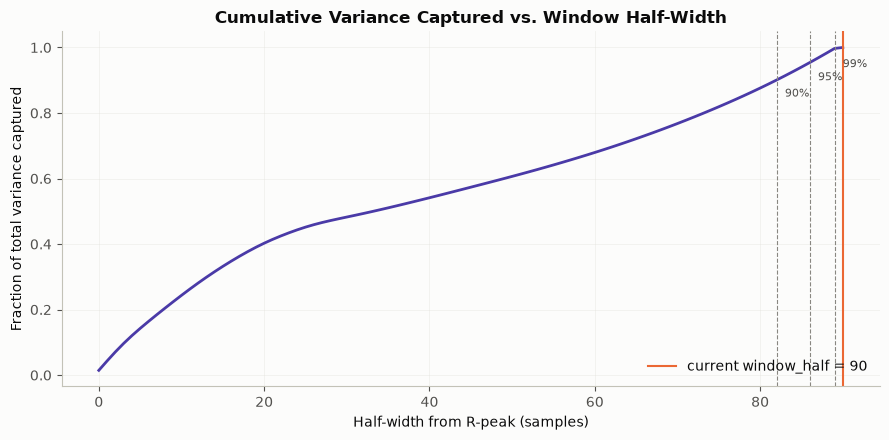

In [35]:
half_widths = np.arange(0, WINDOW_HALF + 1)
frac_by_hw = []
for hw in half_widths:
    inside = dist_from_center <= hw
    frac_by_hw.append(combined_var[inside].sum() / combined_var.sum())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(half_widths, frac_by_hw, color="#4a3aa7", linewidth=2)
for hw, frac, label in [(hw_90, 0.90, "90%"), (hw_95, 0.95, "95%"), (hw_99, 0.99, "99%")]:
    ax.axvline(hw, color="#898781", linewidth=0.8, linestyle="--")
    ax.annotate(label, xy=(hw, frac), xytext=(hw + 1, frac - 0.05), fontsize=8, color="#52514e")
ax.axvline(WINDOW_HALF, color=COLOR_ANOMALY, linewidth=1.5, label=f"current window_half = {WINDOW_HALF}")
ax.set_title("Cumulative Variance Captured vs. Window Half-Width")
ax.set_xlabel("Half-width from R-peak (samples)")
ax.set_ylabel("Fraction of total variance captured")
ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.4)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [36]:
edge_d = np.nanmean(np.concatenate([cohens_d[:10], cohens_d[-10:]]))
center_d = np.nanmean(cohens_d[WINDOW_HALF - 10:WINDOW_HALF + 10])
print(f"Mean standardized effect size within 10 samples of the window edges : {edge_d:.3f}")
print(f"Mean standardized effect size within 10 samples of the R-peak center: {center_d:.3f}")

window_has_slack = hw_99 < WINDOW_HALF
record_finding(
    section="8. Window Analysis",
    observation=(
        f"99% of amplitude variance is captured within a {hw_99}-sample half-width (current "
        f"setting: {WINDOW_HALF}); mean discriminative effect size near the window edges is "
        f"{edge_d:.2f} vs. {center_d:.2f} near the R-peak."
    ),
    motivates_change=(
        f"The current {WINDOW_HALF}-sample half-width already covers 99% or more of amplitude "
        f"variance with margin to spare -- little evidence a longer window is needed; whether a "
        f"shorter window is safe depends on how much of that edge margin the discriminative "
        f"(effect-size) signal actually uses, which is comparable in magnitude to the center here, "
        f"so trimming should be tested carefully rather than assumed safe."
        if window_has_slack else
        f"99% of variance requires close to or more than the current {WINDOW_HALF}-sample "
        f"half-width -- little slack to shrink the window without risking morphology loss."
    ),
    confidence="Medium -- based on aggregate variance/effect-size curves, not a direct ablation "
               "of window size on any downstream metric.",
)

Mean standardized effect size within 10 samples of the window edges : 0.641
Mean standardized effect size within 10 samples of the R-peak center: 0.965


## 9. Summary

The table below is generated directly from the `record_finding(...)` calls made throughout this notebook -- it is not hand-written prose. Re-running the notebook end-to-end regenerates it from whatever the data actually shows on that run.

No specific algorithmic changes to Quorum are proposed here; that is a separate design discussion. What follows is only a structured statement of what the data's temporal characteristics look like, and how strongly each observation argues for looking further into a temporal modification.

In [37]:
findings_df = pd.DataFrame(FINDINGS)
findings_df.index = findings_df.index + 1
findings_df.index.name = "#"

with pd.option_context("display.max_colwidth", None):
    display(findings_df[["section", "observation", "motivates_quorum_change", "confidence"]])

,section,observation,motivates_quorum_change,confidence
#,,,,
1,1. Dataset Overview,"20261 beats loaded from 9 records; 3371/20261 (16.6%) anomalous, spread across 10 distinct annotation labels (dominant: V with 2745 beats).",Confirms the class imbalance Quorum's bucketing already targets; the multi-label anomaly mix is a caveat for any single average-anomaly analysis below.,High -- direct counts from the loaded data.
2,2. Beat Visualization,Mean waveforms diverge most strongly around offset -10 samples from the R-peak; variance envelopes are visibly wider for anomalous beats across most of the window.,Discriminative morphology is not uniformly spread across the 180-sample window -- supports weighting or grouping features by position rather than treating all 180 samples as equally informative.,"Medium -- based on aggregate mean/variance only; individual anomaly sub-types (V, A, F, ...) were not separated here and may peak at different offsets."
3,3. RR Interval Analysis,Normal median RR = 836.1 ms vs. anomalous median RR = 525.0 ms (Mann-Whitney p=0.00e+00); RR sequences also show visibly clustered runs of anomalous beats rather than uniform scattering.,"RR interval carries a statistically significant, and visually clustered, rhythm signal beyond per-beat morphology -- supports treating RR (or local RR context) as its own temporal grouping/bucketing key rather than a single appended scalar.","High for the distributional difference (large n, significant test); medium for how well the clustering pattern generalizes beyond the records plotted."
4,4. Autocorrelation Analysis,Average-waveform ACF drops below 0.5 by lag 6 samples (normal) / 17 samples (anomaly); dominant secondary peaks at [] (normal) vs. [] (anomaly).,Strong short-range autocorrelation means adjacent raw-signal samples are largely redundant -- a feature-grouping scheme that treats every sample as independent (as random per-feature selection does) is spending encoding capacity on correlated information; coarser blocks near the decay lag would not lose much information.,"Medium -- based on average waveforms and a handful of individual-beat examples, not the full per-beat ACF distribution."
5,5. Correlation Analysis,"1 contiguous blocks of adjacent-position Pearson correlation >= 0.9 were found, covering 180/180 (100%) of the window; Pearson and Spearman heatmaps show the same qualitative block structure.","A meaningful fraction of the window is made of near-redundant contiguous positions -- consistent with feature_selection.py strategy 'f' avoiding a single contiguous block, and suggests feature groups could be built directly from these detected blocks (one representative feature per block) rather than from evenly-spaced striding or fully random selection.",High for the correlation structure itself (computed on the full loaded dataset); medium for whether 0.9 is the right threshold for a feature-grouping design.
6,6. DTW Analysis,"Across 1770 sampled pairs, Euclidean/DTW distance correlate at r=0.93; separation ratio (cross-class / within-class mean distance) is 1.47 for Euclidean vs. 1.33 for DTW.",DTW does not separate classes noticeably better than plain Euclidean distance on this sample -- less evidence here that DTW would improve Quorum's bucketing/distance choices beyond what Euclidean already captures.,Medium -- based on a random 30-per-class subsample (not the full dataset) with a fixed Sakoe-Chiba band of 20 samples.
7,7. Similarity Structure,"At k=2, DTW-based hierarchical clusters have average majority-class purity 77.8% (chance level on this balanced subsample is 50%).",DTW-based clusters separate normal from anomalous beats noticeably better than chance on this subsample -- worth prototyping a DTW-similarity-informed bucketing scheme.,"Medium -- same 30-per-class balanced subsample as Section 6, average-linkage clustering only (one linkage method, one k range tested)."
8,8. Window Analysis,99% of amplitude variance is captured within a 89-sample half-wid

In [38]:
print("Findings by confidence level:")
print(findings_df["confidence"].str.split(" --").str[0].value_counts().to_string())

Findings by confidence level:
confidence
Medium                                                                                                                                                           5
High                                                                                                                                                             1
High for the distributional difference (large n, significant test); medium for how well the clustering pattern generalizes beyond the records plotted.           1
High for the correlation structure itself (computed on the full loaded dataset); medium for whether 0.9 is the right threshold for a feature-grouping design.    1


**Where this leaves the design question.** Taken together, these findings sketch a dataset with real temporal structure at three different levels: within-beat morphology (Sections 2, 4, 5, 8), beat-to-beat rhythm (Section 3), and cross-beat similarity (Sections 6, 7). Each level plausibly maps to a different part of Quorum's pipeline -- window/feature design, an RR-aware feature or grouping key, and a similarity-aware bucketing scheme, respectively -- but which of these is worth the implementation cost, and how to implement it, is a follow-up design decision outside the scope of this notebook.